# TP Grupo 10 — Pipeline completo

Este notebook integra todas las etapas del pipeline de preprocesamiento y modelado:  
1. **Carga de librerías**  
2. **Configuración de rutas**  
3. **Carga y split del dataset**  
4. **Data Cleaning** (outliers, nulos, capping)  
5. **Corrida de modelos**

La separación train/test se realiza **antes** de cualquier limpieza para evitar *data leakage*: todos los parámetros de imputación y capping se estiman exclusivamente sobre el conjunto de entrenamiento y luego se aplican al test.

---
### Carga de librerías


In [1]:
# Tablas y matrices
import numpy as np
import pandas as pd
# Gradient Boosting
import lightgbm as lgb
# Funciones auxiliares de sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold  # Split y cross-validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score  # Métricas
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
# Visualización 
from plotly import express as px
import matplotlib.pyplot as plt
# Utilidades del sistema de archivos
import os
# Optimización de hiperparámetros con Optuna
import optuna
from optuna.artifacts import FileSystemArtifactStore, upload_artifact
# Persistencia de modelos entrenados
from joblib import load, dump

from feature_engine.selection import MRMR

c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
### Configuración de rutas y parámetros globales

Se definen todas las rutas de entrada y salida en un único lugar para facilitar su modificación.  
`SEED` garantiza la reproducibilidad de cualquier proceso aleatorio; `TEST_SIZE` controla la proporción del conjunto de test.

In [2]:
# Directorio raíz del proyecto (dos niveles arriba del notebook)
BASE_DIR = '../'

In [3]:
# Datos de entrada
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train/train.csv")

# Splits crudos (antes de limpieza)
PATH_TRAIN_SPLIT = os.path.join(BASE_DIR, 'work/split/train_split.csv')
PATH_TEST_SPLIT  = os.path.join(BASE_DIR, 'work/split/test_split.csv')

# Datasets limpios (después de limpieza)
PATH_TRAIN_CLEAN = os.path.join(BASE_DIR, 'work/cleaned/train_clean.csv')
PATH_TEST_CLEAN  = os.path.join(BASE_DIR, 'work/cleaned/test_clean.csv')

# Salida de modelos entrenados
PATH_TO_MODELS = os.path.join(BASE_DIR, "work/models")

# Artefactos de Optuna
PATH_TO_TEMP_FILES       = os.path.join(BASE_DIR, "work/optuna_temp_artifacts")
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(BASE_DIR, "work/optuna_artifacts")

# Parámetros globales
SEED      = 42   # Semilla para reproducibilidad
TEST_SIZE = 0.2  # Fracción del dataset reservada para test

---
### Carga del dataset y split train/test

Se carga el dataset original de PetFinder y se realiza un **split estratificado** por la variable objetivo `AdoptionSpeed`.  
La estratificación asegura que las proporciones de cada clase queden representadas equitativamente en train y test,  
lo cual es especialmente importante cuando las clases están desbalanceadas.

Los splits se guardan en disco para que puedan ser reutilizados por otras etapas del pipeline sin tener que reejecutar este notebook.

In [4]:
# Carga del dataset completo
dataset = pd.read_csv(PATH_TO_TRAIN)
print(f'Shape: {dataset.shape}')
print(dataset)

Shape: (14993, 24)
       Type            Name  Age  Breed1  Breed2  Gender  Color1  Color2  \
0         2          Nibble    3     299       0       1       1       7   
1         2     No Name Yet    1     265       0       1       1       2   
2         1          Brisco    1     307       0       1       2       7   
3         1            Miko    4     307       0       2       1       2   
4         1          Hunter    1     307       0       1       1       0   
...     ...             ...  ...     ...     ...     ...     ...     ...   
14988     2             NaN    2     266       0       3       1       0   
14989     2  Serato & Eddie   60     265     264       3       1       4   
14990     2         Monkies    2     265     266       3       5       6   
14991     2         Ms Daym    9     266       0       2       4       7   
14992     1            Fili    1     307     307       1       2       0   

       Color3  MaturitySize  ...  Health  Quantity  Fee  State  \
0 

In [5]:
# Split estratificado: 80% train — 20% test
train, test = train_test_split(
    dataset,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=dataset.AdoptionSpeed
)

print(f'Train shape: {train.shape}')
print(f'Test  shape: {test.shape}')

Train shape: (11994, 24)
Test  shape: (2999, 24)


In [6]:
# Guardado de los splits crudos en disco para uso posterior
os.makedirs(os.path.join(BASE_DIR, 'work/split'), exist_ok=True)

train.to_csv(PATH_TRAIN_SPLIT, index=False)
test.to_csv(PATH_TEST_SPLIT,   index=False)

print(f'Train guardado: {PATH_TRAIN_SPLIT}  shape={train.shape}')
print(f'Test  guardado: {PATH_TEST_SPLIT}   shape={test.shape}')

Train guardado: ../work/split/train_split.csv  shape=(11994, 24)
Test  guardado: ../work/split/test_split.csv   shape=(2999, 24)


---
### Data Cleaning

Se aplican correcciones sobre los problemas identificados durante el EDA.  
Toda transformación se **estima sobre train** y luego se aplica a test para evitar data leakage.

| Columna | Problema | Solución |
|---|---|---|
| `Age` | Outliers > 180 meses | Imputar con mediana de train |
| `Name` | Nulos (~8%) | Flag binario + rellenar con cadena vacía |
| `Description` | Nulos (~0.1%) | Flag binario + rellenar con cadena vacía |
| `Fee` | Outliers extremos (hasta 3000 RM) | Capping en percentil 99 de train |

In [7]:
# Resumen de calidad de datos post-split
# Permite identificar columnas con nulos antes de aplicar cualquier limpieza
def quality_summary(df, name):
    summary = pd.DataFrame({
        'Tipo':         [df[c].dtype for c in df.columns],
        '% Nulos':      [(df[c].isnull().mean() * 100).round(2) for c in df.columns],
        'Cardinalidad': [df[c].nunique() for c in df.columns],
    }, index=df.columns)
    print('\n=== ' + name + ' (' + str(df.shape[0]) + ' filas) ===')
    print(summary[summary['% Nulos'] > 0].sort_values('% Nulos', ascending=False).to_string())

quality_summary(train, "TRAIN")
quality_summary(test,  "TEST")


=== TRAIN (11994 filas) ===
               Tipo  % Nulos  Cardinalidad
Name         object     8.44          7433
Description  object     0.08         11285

=== TEST (2999 filas) ===
               Tipo  % Nulos  Cardinalidad
Name         object     8.44          2231
Description  object     0.10          2889


#### Outliers en `Age`

El EDA detectó valores de `Age` de hasta 255 meses (~21 años), que son biológicamente improbables para mascotas en adopción.  
Se reemplazan los valores mayores a 180 meses con la **mediana calculada sobre train** (excluyendo los propios outliers).

In [8]:
# Mediana calculada solo en train, excluyendo los outliers
age_median = train.loc[train["Age"] <= 180, "Age"].median()

# Convertir outliers a NaN y luego imputar con la mediana
train.loc[train["Age"] > 180, "Age"] = np.nan
test.loc[test["Age"]  > 180, "Age"] = np.nan

train["Age"] = train["Age"].fillna(age_median)
test["Age"]  = test["Age"].fillna(age_median)

print(f"Mediana de Age (train, <= 180 meses): {age_median:.0f} meses")
print(f"Mediana de Age (test,  <= 180 meses): {age_median:.0f} meses")
print(f"Train - Age max: {train['Age'].max()}, nulos restantes: {train['Age'].isnull().sum()}") 

Mediana de Age (train, <= 180 meses): 3 meses
Mediana de Age (test,  <= 180 meses): 3 meses
Train - Age max: 180.0, nulos restantes: 0


#### Columna `Name` — nulos

No todos los anunciantes asignan un nombre a la mascota, por lo que los nulos son esperables y tienen significado propio.  
Se crea el flag binario `has_name` (1 = tiene nombre, 0 = no tiene) para que el modelo pueda explotar esta señal,  
y luego se rellenan los nulos con cadena vacía para evitar errores en etapas posteriores.

In [9]:
# Flag: el anunciante completó el nombre (1) o no (0)
train["has_name"] = train["Name"].notna().astype(int)
test["has_name"]  = test["Name"].notna().astype(int)

# Rellenar nulos con cadena vacía para compatibilidad con procesamiento de texto
train["Name"] = train["Name"].fillna("")
test["Name"]  = test["Name"].fillna("")

print(f"Train - % con nombre: {train['has_name'].mean()*100:.1f}%")
print(f"Test  - % con nombre: {test['has_name'].mean()*100:.1f}%")

Train - % con nombre: 91.6%
Test  - % con nombre: 91.6%


#### Columna `Description` — nulos

Igual que `Name`, la descripción es opcional. Los nulos representan anuncios sin texto descriptivo.  
Se aplica el mismo criterio: flag binario `has_description` y relleno con cadena vacía.

In [10]:
# Flag: el anunciante completó la descripción (1) o no (0)
train["has_description"] = train["Description"].notna().astype(int)
test["has_description"]  = test["Description"].notna().astype(int)

# Rellenar nulos con cadena vacía
train["Description"] = train["Description"].fillna("")
test["Description"]  = test["Description"].fillna("")

print(f"Train - % con descripción: {train['has_description'].mean()*100:.1f}%")
print(f"Test  - % con descripción: {test['has_description'].mean()*100:.1f}%")

Train - % con descripción: 99.9%
Test  - % con descripción: 99.9%


#### Outliers en `Fee`

`Fee` presenta valores extremos de hasta 3000 RM, correspondientes a adopciones de razas puras (muy pocos casos).  
En lugar de eliminar estos registros, se aplica **capping** al percentil 99 calculado sobre train:  
los valores que lo superen quedan truncados en ese umbral, reduciendo la influencia de outliers sin pérdida de datos.

In [11]:
# Umbral de capping: percentil 99 calculado sobre train
fee_cap = train["Fee"].quantile(0.99)

train["Fee"] = train["Fee"].clip(upper=fee_cap)
test["Fee"]  = test["Fee"].clip(upper=fee_cap)

print(f"Fee capeado en Train: {fee_cap:.1f} RM")
print(f"Fee capeado en Test:  {fee_cap:.1f} RM")
print(f"Train - Fee max: {train['Fee'].max():.1f}, media: {train['Fee'].mean():.2f}") 

Fee capeado en Train: 350.0 RM
Fee capeado en Test:  350.0 RM
Train - Fee max: 350.0, media: 19.32


---
### Guardado de datasets limpios

Se exportan los datasets resultantes a disco. A partir de aquí, el resto del pipeline (feature engineering, entrenamiento, etc.)  
debe leer `train_clean.csv` y `test_clean.csv` en lugar de los splits crudos.

Cada dataset incorpora las columnas originales más los flags `has_name` y `has_description`, pasando de 24 a 26 columnas.

In [12]:
# Crear directorio de salida si no existe
os.makedirs(os.path.join(BASE_DIR, "work/cleaned"), exist_ok=True)

train.to_csv(PATH_TRAIN_CLEAN, index=False)
test.to_csv(PATH_TEST_CLEAN,   index=False)

print(f"Train limpio guardado: {PATH_TRAIN_CLEAN}  shape={train.shape}")
print(f"Test limpio guardado:  {PATH_TEST_CLEAN}   shape={test.shape}")

Train limpio guardado: ../work/cleaned/train_clean.csv  shape=(11994, 26)
Test limpio guardado:  ../work/cleaned/test_clean.csv   shape=(2999, 26)


In [13]:
train = pd.read_csv(PATH_TRAIN_CLEAN)
test = pd.read_csv(PATH_TEST_CLEAN)

---
### Selección de Features — MRMR con RFCQ

Antes de aplicar MRMR se construye `X_mrmr` eliminando:
- La variable objetivo (`AdoptionSpeed`)
- Identificadores sin valor predictivo (`PetID`, `RescuerID`)
- Variables de texto libre (`Name`, `Description`) que MRMR no puede procesar directamente
- La columna `Type` se recodifica a numérico (`Dog=1`, `Cat=2`) ya que en este punto es string

Esto garantiza que todas las columnas que entran al selector sean numéricas.

In [14]:
X_mrmr = train.drop(columns=['AdoptionSpeed', 'PetID', 'RescuerID', 'Name', 'Description'])
y = train['AdoptionSpeed']

# Recodificamos Type a numérico (en este punto es string 'Dog'/'Cat')
X_mrmr['Type'] = X_mrmr['Type'].map({'Dog': 1, 'Cat': 2})

print(f"Shape de X_mrmr: {X_mrmr.shape}")
print(f"Tipos de datos:\n{X_mrmr.dtypes}")

Shape de X_mrmr: (11994, 21)
Tipos de datos:
Type               float64
Age                float64
Breed1               int64
Breed2               int64
Gender               int64
Color1               int64
Color2               int64
Color3               int64
MaturitySize         int64
FurLength            int64
Vaccinated           int64
Dewormed             int64
Sterilized           int64
Health               int64
Quantity             int64
Fee                  int64
State                int64
VideoAmt             int64
PhotoAmt           float64
has_name             int64
has_description      int64
dtype: object


Se aplica MRMR con el método **RFCQ** (Random Forest + Chi-cuadrado) sobre el dataset limpio.

In [15]:
sel = MRMR(
    method="RFCQ",
    scoring="roc_auc",
    param_grid={"n_estimators": [5, 50, 500], "max_depth": [1, 2, 3]},
    cv=3,
    regression=False,
    random_state=42,
)

sel.fit(X_mrmr, y)

c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\sklearn\metrics\_scorer.py", line 417, in _score
    return self._sign * self._score_func(y_true, y_pred, **scorin

,variables,None
,method,'RFCQ'
,max_features,None
,discrete_features,'auto'
,n_neighbors,3
,scoring,'roc_auc'
,cv,3
,param_grid,"{'max_depth': [1, 2, ...], 'n_estimators': [5, 50, ...]}"
,regression,False
,confirm_variables,False
,random_state,42


Se grafica la relevancia de cada feature. Las barras más altas indican mayor poder predictivo sobre `AdoptionSpeed`.

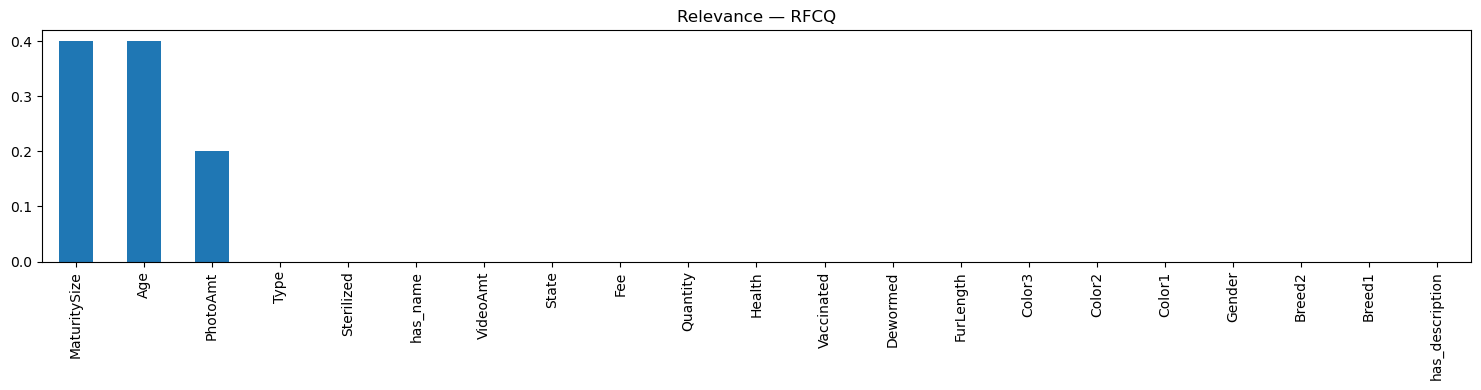

In [16]:
pd.Series(sel.relevance_, index=sel.variables_).sort_values(
    ascending=False).plot.bar(figsize=(15, 4))
plt.title("Relevance — RFCQ")
plt.tight_layout()
plt.show()

---
### Feature Engineering

Se construye `X1` incorporando variables derivadas que pueden capturar información
adicional no presente en las columnas originales.

In [17]:
# Dataset base: sin target, sin identificadores, sin texto libre
X1 = train.drop(columns=["AdoptionSpeed", "PetID", "RescuerID", "Name", "Description"])
y1 = train["AdoptionSpeed"]

print(f"Shape inicial de X1: {X1.shape}")
print(X1)

Shape inicial de X1: (11994, 21)
       Type   Age  Breed1  Breed2  Gender  Color1  Color2  Color3  \
0         1   2.0     307     307       1       1       0       0   
1         1  12.0     307       0       2       2       0       0   
2         1   2.0     307     307       1       1       2       7   
3         1   2.0     307     307       1       3       0       0   
4         2   4.0     265       0       3       1       2       0   
...     ...   ...     ...     ...     ...     ...     ...     ...   
11989     2   8.0     265     299       2       1       2       0   
11990     1   2.0     307       0       2       6       7       0   
11991     1   2.0     307     307       1       1       0       0   
11992     1   2.0     307     307       1       1       2       7   
11993     2  30.0     299     266       1       3       4       5   

       MaturitySize  FurLength  ...  Dewormed  Sterilized  Health  Quantity  \
0                 2          2  ...         1           2  

Se crean dos nuevas variables:
- **`health_score`**: suma de 4 indicadores de salud (vacunación, desparasitación, esterilización, salud general). Rango 0–4.
- **`age_x_MaturitySize`**: interacción entre edad (en años) y tamaño de madurez, normalizada a [0, 1].

In [18]:
X1["health_score"] = (
    (train["Vaccinated"] == 1).astype(int) +
    (train["Dewormed"]   == 1).astype(int) +
    (train["Sterilized"] == 1).astype(int) +
    (train["Health"]     == 1).astype(int)
)

X1["age_x_MaturitySize"] = (X1["Age"] / 12) * X1["MaturitySize"]
scaler = MinMaxScaler()
X1["age_x_MaturitySize"] = scaler.fit_transform(X1[["age_x_MaturitySize"]])

Se categoriza la edad en 3 niveles adaptados al ciclo de vida de cada especie.
Esta variable se crea **antes** de recodificar `Type` a numérico, ya que la función
usa los strings `'Cat'` y `'Dog'`.

In [19]:
def categorizar_edad(row):
    tipo = row["Type"]   # 1 = Perro, 2 = Gato
    edad = row["Age"]

    if tipo == 2:  # Gato
        if 0 <= edad <= 12:  return 1   # cachorro
        elif edad <= 84:     return 2   # adulto
        else:                return 3   # senior
    elif tipo == 1:  # Perro
        if 0 <= edad <= 18:  return 1   # cachorro
        elif edad <= 84:     return 2   # adulto
        else:                return 3   # senior
    return np.nan

X1["Age_level"] = train.apply(categorizar_edad, axis=1)

Variables que capturan qué tan completo y accesible es el perfil de la mascota:
- **`Has_photo`**: binaria, indica si la mascota tiene al menos una foto.
- **`Has_video`**: binaria, indica si la mascota tiene al menos un video.
- **`photo_video_score`**: score compuesto que pondera fotos (×1) y videos (×2), como proxy de riqueza del perfil multimedia.
- **`Is_free`**: binaria, indica si la adopción es gratuita (`Fee == 0`).

In [20]:
X1["Has_photo"]  = (train["PhotoAmt"] > 0).astype(int)
X1["Has_video"]  = (train["VideoAmt"] > 0).astype(int)

# Score multimedia: videos valen el doble que fotos (más esfuerzo de producción)
X1["photo_video_score"] = train["PhotoAmt"] + train["VideoAmt"] * 2

X1["Is_free"] = (train["Fee"] == 0).astype(int)

- **`Is_mixed_breed`**: binaria, indica si la mascota tiene una segunda raza registrada (mestizo).
- **`Is_group`**: binaria, indica si el perfil representa más de una mascota. Adoptar un grupo puede ser más difícil.

In [21]:
X1["Is_mixed_breed"] = (train["Breed2"] != 0).astype(int)

X1["Is_group"] = (train["Quantity"] > 1).astype(int)

Se complementa el `health_score` ya existente con dos variables adicionales:
- **`health_complete`**: binaria, indica si la mascota cumple los 4 indicadores de salud. Puede ser más informativa que el score numérico para algunos modelos.
- **`health_unknown`**: cuenta cuántos de los 3 indicadores principales (vacunación, desparasitación, esterilización) tienen valor `3` (No sabe). Un perfil con muchos "No sé" puede generar desconfianza en el adoptante.


In [22]:
# Salud completa: cumple los 4 indicadores
X1["health_complete"] = (X1["health_score"] == 4).astype(int)

# Indicadores de salud desconocidos (valor 3 = No sabe)
X1["health_unknown"] = (
    (train["Vaccinated"] == 3).astype(int) +
    (train["Dewormed"]   == 3).astype(int) +
    (train["Sterilized"] == 3).astype(int)
)

Se extraen dos segmentos extremos de la distribución de edad, que suelen tener comportamientos de adopción muy distintos al resto:
- **`Is_baby`**: binaria, gatos ≤ 3 meses o perros ≤ 4 meses. Los cachorros muy jóvenes tienden a adoptarse rápido.
- **`Is_senior`**: binaria, `Age_level == 3`. Los animales senior son el segmento más difícil de adoptar.
- **`Has_name`**: incorporada desde el EDA. Indica si la mascota tiene nombre registrado.

In [23]:
# Bebé: umbral diferenciado por especie (Type 1=Perro, 2=Gato)
def es_bebe(row):
    if row["Type"] == 2:   # Gato
        return int(row["Age"] <= 3)
    elif row["Type"] == 1:  # Perro
        return int(row["Age"] <= 4)
    return 0

X1["Is_baby"]   = train.apply(es_bebe, axis=1)
X1["Is_senior"] = (X1["Age_level"] == 3).astype(int)


Feature del Rescatador

- **`rescuer_listings`**: cantidad de perfiles publicados por el mismo rescatador. Un rescatador con muchas publicaciones puede tener más experiencia generando perfiles atractivos, o puede indicar un refugio con alta rotación.

In [27]:
rescuer_counts = train["RescuerID"].value_counts()
X1["rescuer_listings"] = train["RescuerID"].map(rescuer_counts)

Se verifica la forma y los nombres de columnas de `X1` antes de aplicar MRMR.

In [24]:
print(f"Shape final de X1: {X1.shape}")
print(f"\nColumnas ({len(X1.columns)}):")
print(list(X1.columns))
#print(X1)

Shape final de X1: (11994, 34)

Columnas (34):
['Type', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'VideoAmt', 'PhotoAmt', 'has_name', 'has_description', 'health_score', 'age_x_MaturitySize', 'Age_level', 'Has_photo', 'Has_video', 'photo_video_score', 'Is_free', 'Is_mixed_breed', 'Is_group', 'health_complete', 'health_unknown', 'Is_baby', 'Is_senior']


---
### Selección de Features sobre X1 Completo — RFCQ y MIQ

Para la selección final se corren **ambos métodos sobre el mismo dataset `X1`**, que incluye
tanto las variables originales como todas las features derivadas del ingeniería de features.
Esto garantiza que la comparación entre métodos sea válida: ambos evalúan exactamente
el mismo conjunto de variables.

El vector `discrete_cols` se genera automáticamente a partir de los dtypes de `X1`.

In [25]:
# Generamos discrete_cols automáticamente según el dtype de cada columna
# Se consideran discretas las columnas de tipo int (categóricas codificadas)
# y continuas las de tipo float
discrete_cols = [X1[col].dtype == int for col in X1.columns]

print("Columnas y tipo (True=discreta, False=continua):")
for col, d in zip(X1.columns, discrete_cols):
    print(f"  {col:25s} {'discreta' if d else 'continua'}")

Columnas y tipo (True=discreta, False=continua):
  Type                      continua
  Age                       continua
  Breed1                    continua
  Breed2                    continua
  Gender                    continua
  Color1                    continua
  Color2                    continua
  Color3                    continua
  MaturitySize              continua
  FurLength                 continua
  Vaccinated                continua
  Dewormed                  continua
  Sterilized                continua
  Health                    continua
  Quantity                  continua
  Fee                       continua
  State                     continua
  VideoAmt                  continua
  PhotoAmt                  continua
  has_name                  continua
  has_description           continua
  health_score              discreta
  age_x_MaturitySize        continua
  Age_level                 continua
  Has_photo                 discreta
  Has_video               

In [26]:
sel_rfcq = MRMR(
    method="RFCQ",
    scoring="roc_auc",
    param_grid={"n_estimators": [5, 50, 500], "max_depth": [1, 2, 3]},
    cv=3,
    regression=False,
    random_state=SEED,
)
sel_rfcq.fit(X1, y1)

c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\sklearn\metrics\_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\sklearn\metrics\_scorer.py", line 417, in _score
    return self._sign * self._score_func(y_true, y_pred, **scorin

,variables,None
,method,'RFCQ'
,max_features,None
,discrete_features,'auto'
,n_neighbors,3
,scoring,'roc_auc'
,cv,3
,param_grid,"{'max_depth': [1, 2, ...], 'n_estimators': [5, 50, ...]}"
,regression,False
,confirm_variables,False
,random_state,42


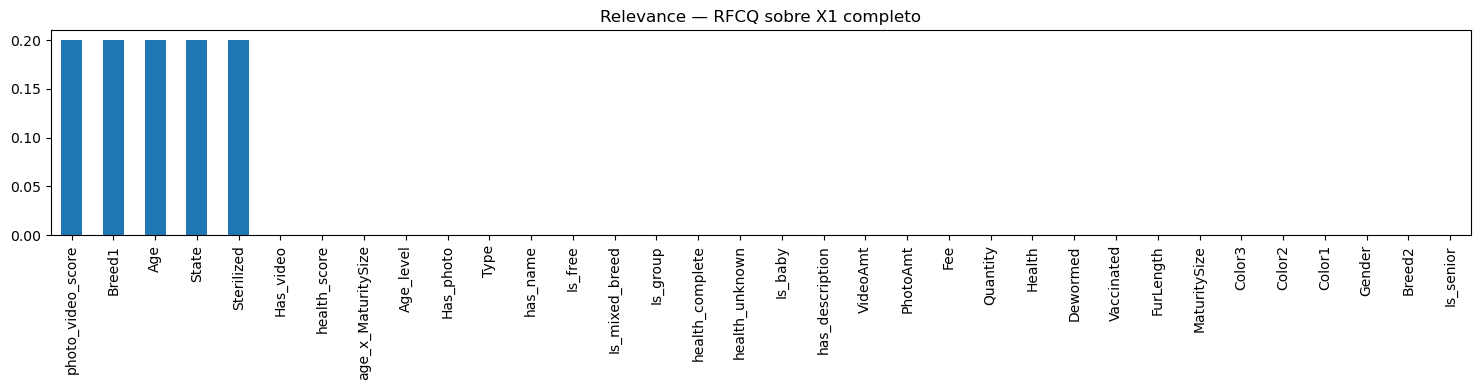

In [27]:
pd.Series(sel_rfcq.relevance_, index=sel_rfcq.variables_).sort_values(
    ascending=False).plot.bar(figsize=(15, 4))
plt.title("Relevance — RFCQ sobre X1 completo")
plt.tight_layout()
plt.show()

In [28]:
np.random.seed(SEED)
sel2 = MRMR(method="MIQ", regression=False, discrete_features=discrete_cols)
sel2.fit(X1, y1)

c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\feature_engine\selection\mrmr.py:465: RuntimeWarning: divide by zero encountered in divide
  mrmr = relevance / redundance


,variables,None
,method,'MIQ'
,max_features,None
,discrete_features,"[False, False, ...]"
,n_neighbors,3
,scoring,'roc_auc'
,cv,3
,param_grid,None
,regression,False
,confirm_variables,False
,random_state,None


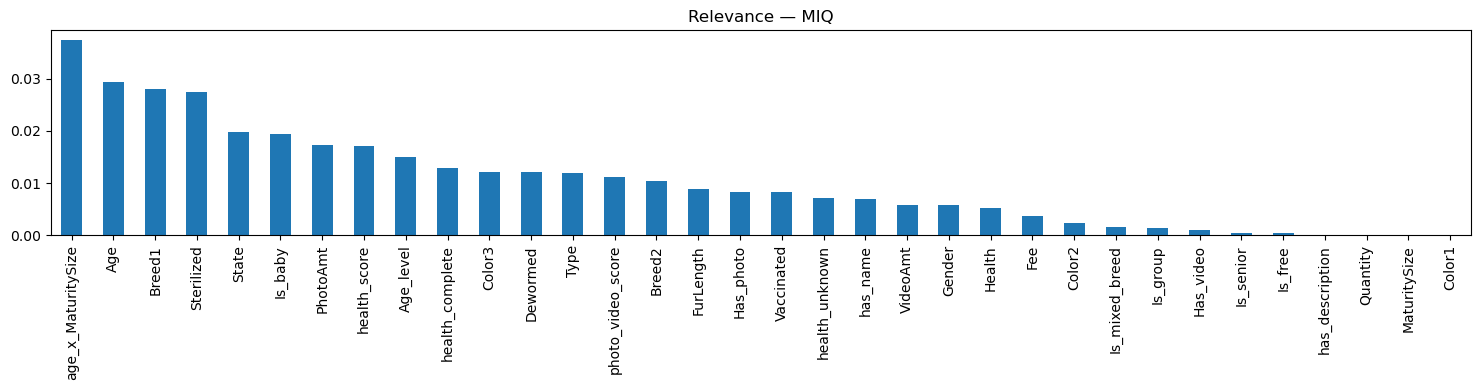

In [29]:
pd.Series(sel2.relevance_, index=sel2.variables_).sort_values(
    ascending=False).plot.bar(figsize=(15, 4))
plt.title("Relevance — MIQ")
plt.tight_layout()
plt.show()

---
### Comparación y Selección Final de Features

Se comparan los rankings de relevancia de ambos métodos (RFCQ y MIQ) para identificar
las features que ambos coinciden en valorar. Las features que aparecen en el top de
ambos métodos son las candidatas más robustas para el modelo.

In [30]:
# Ambos selectores corrieron sobre X1 — la comparación es válida
relevance_rfcq = pd.Series(sel_rfcq.relevance_, index=sel_rfcq.variables_).sort_values(ascending=False)
relevance_miq  = pd.Series(sel2.relevance_,     index=sel2.variables_).sort_values(ascending=False)

# Ranking de cada feature en cada método (1 = más relevante)
rank_rfcq = relevance_rfcq.rank(ascending=False).rename("Rank_RFCQ")
rank_miq  = relevance_miq.rank(ascending=False).rename("Rank_MIQ")

# Como ambos métodos evaluaron exactamente las mismas variables, no hay NaN
comparison = pd.concat([rank_rfcq, rank_miq], axis=1)
comparison["Rank_promedio"] = comparison.mean(axis=1)
comparison = comparison.sort_values("Rank_promedio")

print("Features ordenadas por ranking promedio (RFCQ + MIQ sobre X1):")
print(comparison.round(1).to_string())

Features ordenadas por ranking promedio (RFCQ + MIQ sobre X1):
                    Rank_RFCQ  Rank_MIQ  Rank_promedio
Age                       3.0       2.0            2.5
Breed1                    3.0       3.0            3.0
Sterilized                3.0       4.0            3.5
State                     3.0       5.0            4.0
photo_video_score         3.0      14.0            8.5
age_x_MaturitySize       20.0       1.0           10.5
Is_baby                  20.0       6.0           13.0
PhotoAmt                 20.0       7.0           13.5
health_score             20.0       8.0           14.0
Age_level                20.0       9.0           14.5
health_complete          20.0      10.0           15.0
Color3                   20.0      11.0           15.5
Dewormed                 20.0      12.0           16.0
Type                     20.0      13.0           16.5
Breed2                   20.0      15.0           17.5
FurLength                20.0      16.0           18.0
Ha

In [31]:
# Features seleccionadas: top N con mejor ranking promedio
N = 10
features_seleccionadas = comparison.head(N).index.tolist()

print(f"\nTop {N} features seleccionadas para el modelo:")
for i, f in enumerate(features_seleccionadas, 1):
    print(f"  {i:2d}. {f}")


Top 10 features seleccionadas para el modelo:
   1. Age
   2. Breed1
   3. Sterilized
   4. State
   5. photo_video_score
   6. age_x_MaturitySize
   7. Is_baby
   8. PhotoAmt
   9. health_score
  10. Age_level


---
## Modelado — LightGBM con tres configuraciones de features

Se entrena y evalúa un modelo LightGBM optimizado con Optuna sobre tres conjuntos de features:

- **Modelo 1 — Variables originales**: las columnas del dataset limpio sin ninguna feature derivada.
- **Modelo 2 — Variables completas**: originales + features de ingeniería (X1).
- **Modelo 3 — Top 10 MRMR**: las 10 variables seleccionadas por ranking promedio RFCQ + MIQ.

La métrica principal es el **Cohen Kappa cuadrático**, que penaliza el azar y maneja el desbalance de clases.

### Imports y parámetros de modelado

In [32]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
import lightgbm as lgb
import optuna
import seaborn as sns
from joblib import dump

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_FOLDS  = 5
TARGET   = "AdoptionSpeed"
os.makedirs(PATH_TO_MODELS, exist_ok=True)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

### Preparación de los tres conjuntos de features

**Encoding de categóricas:** LightGBM requiere valores numéricos. Se aplica  ajustado sobre train y aplicado a test para evitar *data leakage*.

Las columnas de texto libre (, ) y los identificadores (, ) se descartan en todos los conjuntos.

In [33]:
# ── Columnas a descartar siempre ──────────────────────────────────────────
DROP_ALWAYS = ["PetID", "RescuerID", "Name", "Description"]

# ── Variables categóricas a encodear ──────────────────────────────────────
CAT_COLS = ["Type", "Gender", "Color1", "Color2", "Color3",
            "MaturitySize", "FurLength", "Vaccinated", "Dewormed",
            "Sterilized", "Health", "Breed1", "Breed2", "State"]

def encode_cats(train_df, test_df, cat_cols):
    """Label-encode cat_cols sobre train, aplica a test (unseen → 0)."""
    train_df = train_df.copy()
    test_df  = test_df.copy()
    for col in cat_cols:
        if col not in train_df.columns:
            continue
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        test_df[col]  = test_df[col].astype(str).map(
            lambda x, le=le: le.transform([x])[0] if x in le.classes_ else 0
        )
    return train_df, test_df

# ── Modelo 1: variables originales ────────────────────────────────────────
train_orig = train.drop(columns=DROP_ALWAYS + [TARGET], errors="ignore")
test_orig  = test.drop(columns=DROP_ALWAYS + [TARGET], errors="ignore")
train_orig, test_orig = encode_cats(train_orig, test_orig, CAT_COLS)

X1_train = train_orig
X1_test  = test_orig
y_train  = train[TARGET]
y_test   = test[TARGET]

print(f"Modelo 1 — shape train: {X1_train.shape}, test: {X1_test.shape}")


Modelo 1 — shape train: (11994, 21), test: (2999, 21)


In [34]:
# ── Modelo 2: variables completas (originales + features de ingeniería) ───
# X1 ya fue construido en la sección de Feature Engineering (contiene train)
# Se replica el mismo proceso para el conjunto de test

def build_features(df, rescuer_counts_map):
    """Aplica el mismo feature engineering que se hizo sobre train."""
    df = df.copy()

    # desc_len antes de descartar Description
    df["desc_len"] = df["Description"].fillna("").str.split().str.len()

    df["rescuer_listings"] = df["RescuerID"].map(rescuer_counts_map).fillna(1).astype(int)
    df = df.drop(columns=DROP_ALWAYS, errors="ignore")

    df["health_score"] = (
        (df["Vaccinated"] == 1).astype(int) +
        (df["Dewormed"]   == 1).astype(int) +
        (df["Sterilized"] == 1).astype(int) +
        (df["Health"]     == 1).astype(int)
    )

    df["age_x_MaturitySize"] = (df["Age"] / 12) * df["MaturitySize"]
    scaler_local = MinMaxScaler()
    df["age_x_MaturitySize"] = scaler_local.fit_transform(df[["age_x_MaturitySize"]])

    def cat_edad(row):
        tipo, edad = row["Type"], row["Age"]
        if tipo == 2:  return 1 if edad <= 12 else (2 if edad <= 84 else 3)
        if tipo == 1:  return 1 if edad <= 18 else (2 if edad <= 84 else 3)
        return np.nan

    df["Age_level"] = df.apply(cat_edad, axis=1)

    df["Has_photo"]         = (df["PhotoAmt"] > 0).astype(int)
    df["Has_video"]         = (df["VideoAmt"] > 0).astype(int)
    df["photo_video_score"] = df["PhotoAmt"] + df["VideoAmt"] * 2
    df["Is_free"]           = (df["Fee"] == 0).astype(int)
    df["Is_mixed_breed"]    = (df["Breed2"] != 0).astype(int)
    df["Is_group"]          = (df["Quantity"] > 1).astype(int)
    df["health_complete"]   = (df["health_score"] == 4).astype(int)
    df["health_unknown"]    = (
        (df["Vaccinated"] == 3).astype(int) +
        (df["Dewormed"]   == 3).astype(int) +
        (df["Sterilized"] == 3).astype(int)
    )

    def es_bebe(row):
        if row["Type"] == 2: return int(row["Age"] <= 3)
        if row["Type"] == 1: return int(row["Age"] <= 4)
        return 0

    df["Is_baby"]          = df.apply(es_bebe, axis=1)
    df["Is_senior"]        = (df["Age_level"] == 3).astype(int)
    #df["rescuer_listings"] = df.index.map(lambda i: rescuer_counts_map.get(i, 1))

    return df

# rescuer_counts calculado sobre train (evita leakage)
rescuer_counts = train["RescuerID"].value_counts().to_dict()

X2_train_raw = build_features(train, rescuer_counts)
X2_test_raw  = build_features(test,  rescuer_counts)

# Alineamos columnas
common_cols = [c for c in X2_train_raw.columns if c in X2_test_raw.columns and c != TARGET]
X2_train_raw = X2_train_raw[common_cols]
X2_test_raw  = X2_test_raw[common_cols]

X2_train, X2_test = encode_cats(X2_train_raw, X2_test_raw,
                                [c for c in CAT_COLS if c in common_cols])

print(f"Modelo 2 — shape train: {X2_train.shape}, test: {X2_test.shape}")


Modelo 2 — shape train: (11994, 36), test: (2999, 36)


Guardamos los dataset con todos los features

In [35]:
X2_train_save = X2_train.copy()
X2_train_save["AdoptionSpeed"] = y_train.values

os.makedirs(os.path.join(BASE_DIR, "work/cleaned"), exist_ok=True)
X2_train_save.to_csv(os.path.join(BASE_DIR, "work/cleaned/train_X2.csv"), index=False)
X2_test.to_csv(os.path.join(BASE_DIR, "work/cleaned/test_X2.csv"), index=False)

print(f"Train guardado: shape={X2_train_save.shape}")
print(f"Test  guardado: shape={X2_test.shape}")


Train guardado: shape=(11994, 37)
Test  guardado: shape=(2999, 36)


In [48]:
# ── Modelo 3: top 10 features MRMR ────────────────────────────────────────
# features_seleccionadas fue definido en la celda de selección final (N=10)
cols_mrmr_train = [c for c in features_seleccionadas if c in X2_train.columns]
cols_mrmr_test  = [c for c in features_seleccionadas if c in X2_test.columns]

X3_train = X2_train[cols_mrmr_train]
X3_test  = X2_test[cols_mrmr_test]

print(f"Modelo 3 — shape train: {X3_train.shape}, test: {X3_test.shape}")
print(f"Features MRMR usadas: {cols_mrmr_train}")


Modelo 3 — shape train: (11994, 10), test: (2999, 10)
Features MRMR usadas: ['age_x_MaturitySize', 'Age', 'PhotoAmt', 'health_score', 'health_complete', 'rescuer_listings', 'Breed1', 'Sterilized', 'Breed2', 'photo_video_score']


### Función de entrenamiento con Optuna

Se define una función reutilizable que:
1. Corre **100 trials de Optuna** para optimizar hiperparámetros (Kappa cuadrático como métrica).
2. Entrena el modelo final con los mejores params sobre el 90% del train.
3. Evalúa sobre test y grafica la matriz de confusión e importancia de features.

In [53]:
def entrenar_modelo(X_tr, X_te, y_tr, y_te, nombre_modelo, n_trials=100):
    """
    Entrena LightGBM con tuneo Optuna y evalúa sobre test.
    Retorna el modelo final y las métricas.
    """
    print(f" {'=' * 60}")
    print(f"  {nombre_modelo}")
    print(f"{'=' * 60}")

    skf_local = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    # ── Tuneo con Optuna ───────────────────────────────────────
    def objective(trial):
        params = {
            "objective":         "multiclass",
            "num_class":         5,
            "metric":            "multi_logloss",
            "verbosity":         -1,
            "random_state":      SEED,
            "class_weight":      "balanced",
            "n_estimators":      500,
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
            "max_depth":         trial.suggest_int("max_depth", 3, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        }
        kappas = []
        for idx_tr, idx_val in skf_local.split(X_tr, y_tr):
            X_f, X_v = X_tr.iloc[idx_tr], X_tr.iloc[idx_val]
            y_f, y_v = y_tr.iloc[idx_tr], y_tr.iloc[idx_val]
            m = lgb.LGBMClassifier(**params)
            m.fit(X_f, y_f, eval_set=[(X_v, y_v)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(-1)])
            kappas.append(cohen_kappa_score(y_v, m.predict(X_v), weights="quadratic"))
        return np.mean(kappas)

    study = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  Mejor Kappa CV: {study.best_value:.4f}")
    print(f"  Mejores params: {study.best_params}")

    # ── Entrenamiento final ────────────────────────────────────
    best_params = {
        "objective":    "multiclass",
        "num_class":    5,
        "metric":       "multi_logloss",
        "verbosity":    -1,
        "random_state": SEED,
        "n_estimators": 1000,
        "class_weight": "balanced",
        **study.best_params
    }

    X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(
        X_tr, y_tr, test_size=0.1, random_state=SEED, stratify=y_tr
    )

    model = lgb.LGBMClassifier(**best_params)
    model.fit(X_tr_f, y_tr_f, eval_set=[(X_val_f, y_val_f)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)])

    # Guardar modelo
    model_name = nombre_modelo.lower().replace(" ", "_").replace("—", "").strip("_")
    dump(model, os.path.join(PATH_TO_MODELS, f"lgbm_{model_name}.joblib"))

    # ── Evaluación en test ─────────────────────────────────────
    y_pred  = model.predict(X_te)
    kappa   = cohen_kappa_score(y_te, y_pred, weights="quadratic")
    acc     = accuracy_score(y_te, y_pred)
    bal_acc = balanced_accuracy_score(y_te, y_pred)

    print(f" === Métricas en test ===")
    print(f"  Cohen Kappa (quadratic): {kappa:.4f}")
    print(f"  Accuracy:                {acc:.4f}")
    print(f"  Balanced Accuracy:       {bal_acc:.4f}")

    # ── Matriz de confusión ────────────────────────────────────
    cm = confusion_matrix(y_te, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=[f"Pred {i}" for i in range(5)],
                yticklabels=[f"Real {i}" for i in range(5)])
    axes[0].set_title(f"Matriz de confusión {nombre_modelo}")
    axes[0].set_ylabel("Clase real")
    axes[0].set_xlabel("Clase predicha")

    # ── Importancia de features ────────────────────────────────
    importance = pd.DataFrame({
        "feature":    X_tr.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    top_n = min(20, len(importance))
    sns.barplot(data=importance.head(top_n), x="importance", y="feature",
                palette="viridis", ax=axes[1])
    axes[1].set_title(f"Top {top_n} features por importancia {nombre_modelo}")
    plt.tight_layout()
    plt.show()

    return model, {"kappa": kappa, "accuracy": acc, "balanced_accuracy": bal_acc}


### Modelo 1 — Variables originales

  Modelo 1 — Variables originales


  0%|          | 0/100 [00:00<?, ?it/s]

Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\Usuario\anaconda\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\Usuario\anaconda\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Users\Usuario\anaconda\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Usuario\anaconda\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "c:\Users\Usuario\anaconda\Lib\codecs.py", line 325, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
                         ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 108: invalid start byte


  Mejor Kappa CV: 0.3620
  Mejores params: {'learning_rate': 0.03449768600674923, 'num_leaves': 298, 'max_depth': 12, 'min_child_samples': 9, 'subsample': 0.5455477864580761, 'colsample_bytree': 0.6194684970662544, 'reg_alpha': 0.07666608513797096, 'reg_lambda': 0.39805808607113885}
 === Métricas en test ===
  Cohen Kappa (quadratic): 0.3127
  Accuracy:                0.3818
  Balanced Accuracy:       0.3354


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18068\657146959.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(top_n), x="importance", y="feature",


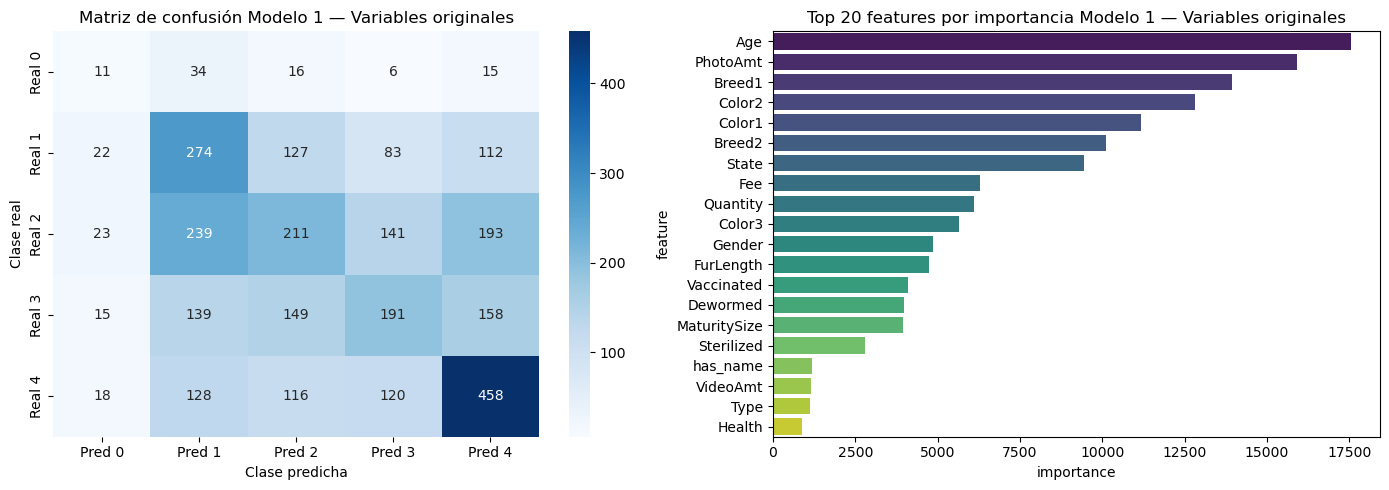

In [54]:
model1, metrics1 = entrenar_modelo(
    X1_train, X1_test, y_train, y_test,
    nombre_modelo="Modelo 1 — Variables originales"
)


### Modelo 2 — Variables completas (originales + feature engineering)

  Modelo 2 — Variables completas


  0%|          | 0/100 [00:00<?, ?it/s]

  Mejor Kappa CV: 0.3705
  Mejores params: {'learning_rate': 0.01456962454946216, 'num_leaves': 102, 'max_depth': 11, 'min_child_samples': 37, 'subsample': 0.8000753396599006, 'colsample_bytree': 0.5710719916896971, 'reg_alpha': 0.9107990914466315, 'reg_lambda': 0.02198297017075546}
 === Métricas en test ===
  Cohen Kappa (quadratic): 0.3191
  Accuracy:                0.3831
  Balanced Accuracy:       0.3374


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18068\657146959.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(top_n), x="importance", y="feature",


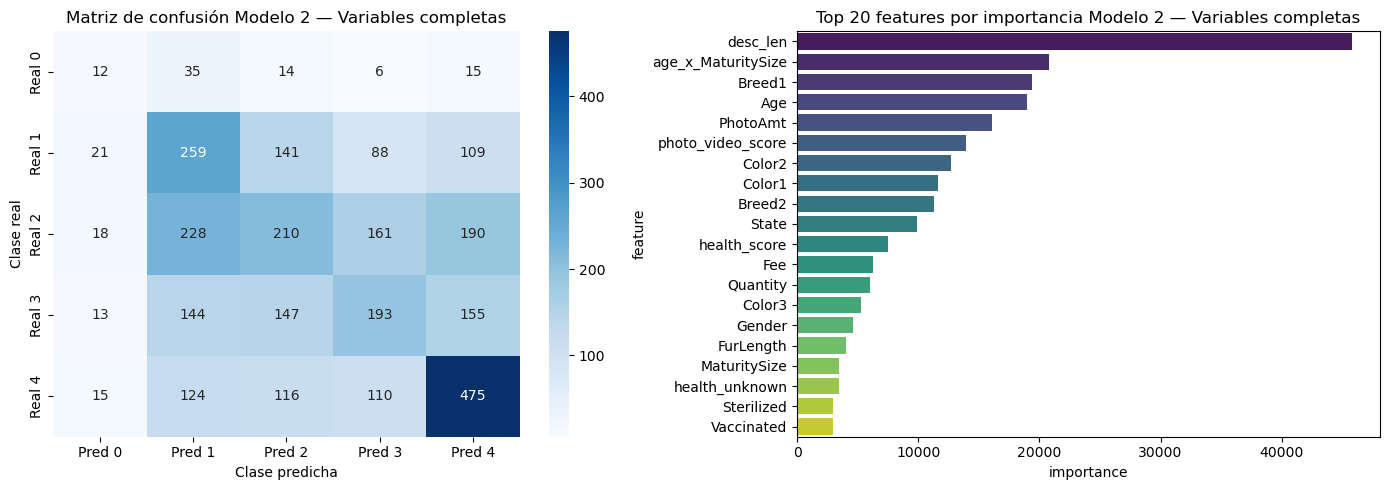

In [55]:
model2, metrics2 = entrenar_modelo(
    X2_train, X2_test, y_train, y_test,
    nombre_modelo="Modelo 2 — Variables completas"
)


### Modelo 3 — Top 10 features MRMR

  Modelo 3 — Top 10 MRMR


  0%|          | 0/100 [00:00<?, ?it/s]

  Mejor Kappa CV: 0.3066
  Mejores params: {'learning_rate': 0.052819809952322855, 'num_leaves': 196, 'max_depth': 6, 'min_child_samples': 11, 'subsample': 0.6721102395195497, 'colsample_bytree': 0.7046518985037608, 'reg_alpha': 0.0014250121765616505, 'reg_lambda': 2.343541947679249e-05}
 === Métricas en test ===
  Cohen Kappa (quadratic): 0.2447
  Accuracy:                0.3351
  Balanced Accuracy:       0.3070


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18068\657146959.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(top_n), x="importance", y="feature",


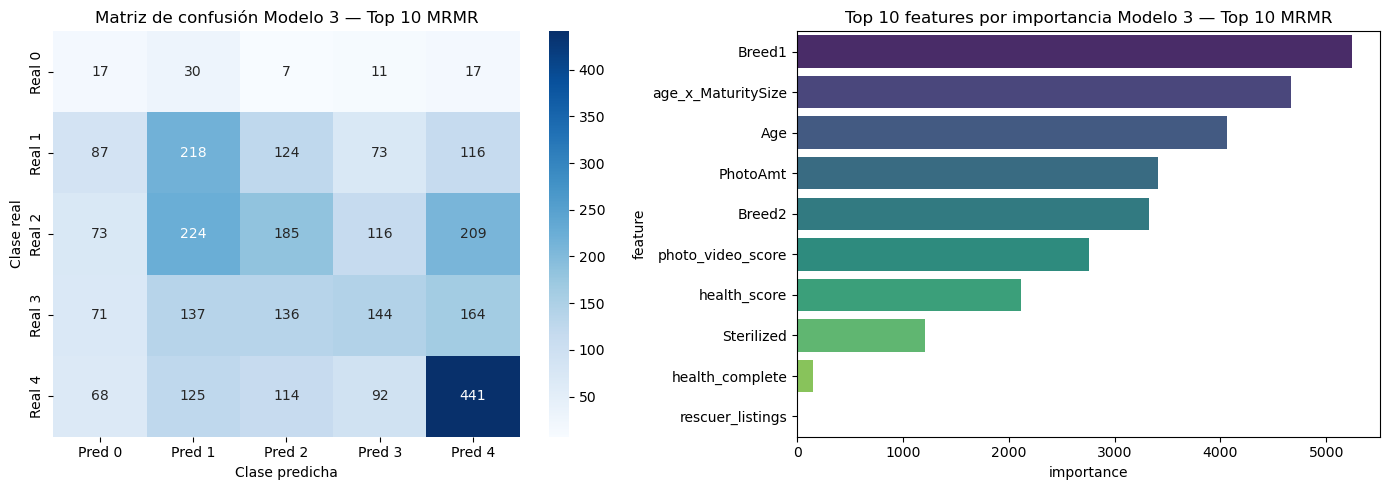

In [56]:
model3, metrics3 = entrenar_modelo(
    X3_train, X3_test, y_train, y_test,
    nombre_modelo="Modelo 3 — Top 10 MRMR"
)


### Comparación final de los tres modelos

                          Cohen Kappa  Accuracy  Balanced Acc  N features
Modelo                                                                   
1 — Variables originales       0.3127    0.3818        0.3354          21
2 — Variables completas        0.3191    0.3831        0.3374          36
3 — Top 10 MRMR                0.2447    0.3351        0.3070          10


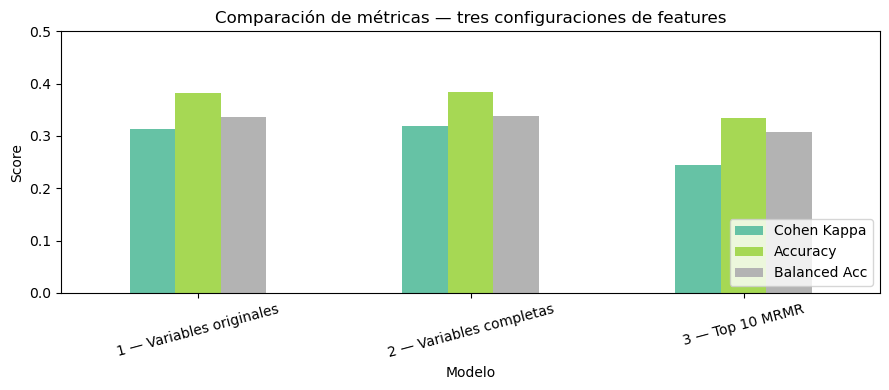

In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "1 — Variables originales",
        "2 — Variables completas",
        "3 — Top 10 MRMR"
    ],
    "Cohen Kappa": [metrics1["kappa"], metrics2["kappa"], metrics3["kappa"]],
    "Accuracy":    [metrics1["accuracy"], metrics2["accuracy"], metrics3["accuracy"]],
    "Balanced Acc":[metrics1["balanced_accuracy"], metrics2["balanced_accuracy"], metrics3["balanced_accuracy"]],
    "N features":  [X1_train.shape[1], X2_train.shape[1], X3_train.shape[1]]
})

resultados = resultados.set_index("Modelo")
print(resultados.round(4).to_string())

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(9, 4))
resultados[["Cohen Kappa", "Accuracy", "Balanced Acc"]].plot(
    kind="bar", ax=ax, colormap="Set2", rot=15
)
ax.set_title("Comparación de métricas — tres configuraciones de features")
ax.set_ylabel("Score")
ax.set_ylim(0, 0.5)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
